# pltx Showcase Notebook

A comprehensive walkthrough of all `pltx` features, translated from `examples/showcase.py`.

> **Sections**
> 1. Setup & style initialisation
> 2. **Pasqal colormap** (from `cmap/`)

## 1 · Setup

In [1]:
import sys
import os

# Make sure we can import pltx from the repo root
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import matplotlib.pyplot as mpl_plt
import pltx.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Common data used throughout the notebook
x  = np.linspace(0, 10, 200)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.sin(x) * np.exp(-0.1 * x)
noise = 0.1 * np.random.randn(len(x))

# Initialise global style
plt.initialize_style(
    palette_name='plasma_r',
    palette_size=10,
    font_size_medium=11,
    font_size_large=13,
    use_tex=False,
)
print('pltx ready ✓')

pltx ready ✓


## 2 · Pasqal Custom Colormaps (`pltx.cmap`)

The `pltx/cmap/` subpackage ships three `.npy` files with hand-crafted Pasqal colour maps:
- `pasqal_cmap.npy` — main Pasqal brand colourmap
- `pasqal_contrast_cmap.npy` — higher-contrast variant
- `pasqal_diverging.npy` — diverging colourmap centred on white

All three are **auto-registered** when you `import pltx`, so no manual setup is needed.
Below we demonstrate them on 2-D heatmaps and colour swatches.

In [2]:
# Colormaps are auto-registered on `import pltx` — nothing to do here.
# Verify they are available:
print('Available Pasqal colormaps:', [n for n in mpl_plt.colormaps() if 'pasqal' in n])

Available Pasqal colormaps: ['pasqal', 'pasqal_contrast', 'pasqal_diverging']


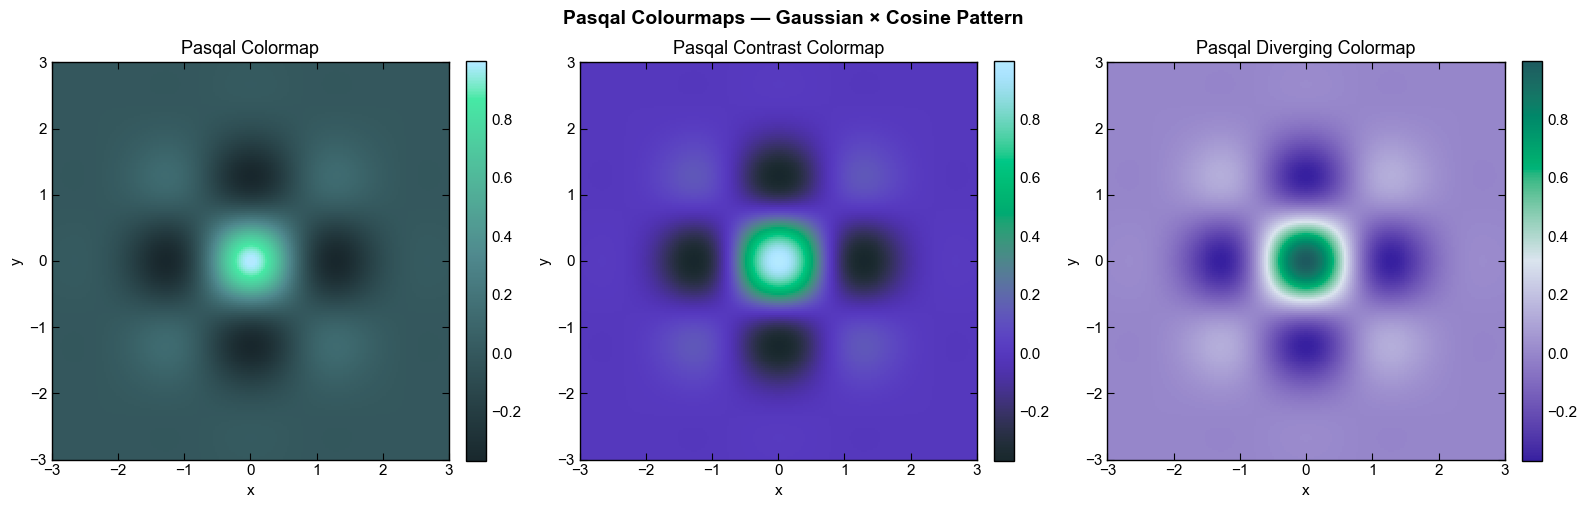

In [3]:
# ── Demo data: 2-D Gaussian + sine modulation ─────────────────────────────────
grid_x, grid_y = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
Z = np.exp(-(grid_x**2 + grid_y**2) / 2) * np.cos(2 * grid_x) * np.cos(2 * grid_y)

fig, axes = mpl_plt.subplots(1, 3, figsize=(16, 5))

for ax, cmap_name, title in zip(
    axes,
    ['pasqal', 'pasqal_contrast', 'pasqal_diverging'],
    ['Pasqal Colormap', 'Pasqal Contrast Colormap', 'Pasqal Diverging Colormap'],
):
    im = ax.imshow(Z, cmap=cmap_name, origin='lower',
                   extent=[-3, 3, -3, 3], aspect='equal')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.setup_axis(ax, xlabel='x', ylabel='y', title=title)

fig.suptitle('Pasqal Colourmaps — Gaussian × Cosine Pattern',
             fontsize=14, fontweight='bold')
mpl_plt.tight_layout()
mpl_plt.show()

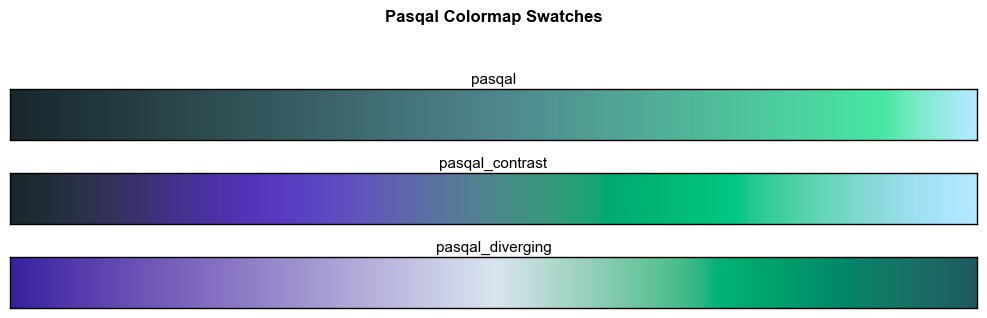

In [4]:
# ── Colormap swatch ───────────────────────────────────────────────────────────
fig, axes = mpl_plt.subplots(3, 1, figsize=(10, 3))

for ax, name in zip(axes, ['pasqal', 'pasqal_contrast', 'pasqal_diverging']):
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax.imshow(gradient, aspect='auto', cmap=name)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(name, fontsize=11, pad=4)

mpl_plt.suptitle('Pasqal Colormap Swatches', fontsize=12, fontweight='bold', y=1.05)
mpl_plt.tight_layout()
mpl_plt.show()

### 2b · Pasqal Colourmaps on Sine & Cosine Plots

A colourmap doesn't have to stay on 2-D images.
Here we sample **N evenly-spaced colours** from the registered Pasqal colourmaps and use them to colour a family of **phase-shifted sine and cosine curves**.
This lets you see the full gradient in a line-plot context — and highlights how the three maps differ in perceptual contrast.

Key steps:
1. Sample `N` colours from the colormap using `mpl_plt.get_cmap(name)(i / (N-1))`.
2. Plot `sin(x + φᵢ)` and `cos(x + φᵢ)` for each phase φᵢ, coloured accordingly.
3. Add a `ScalarMappable` colorbar so the viewer can read off which phase corresponds to which colour.

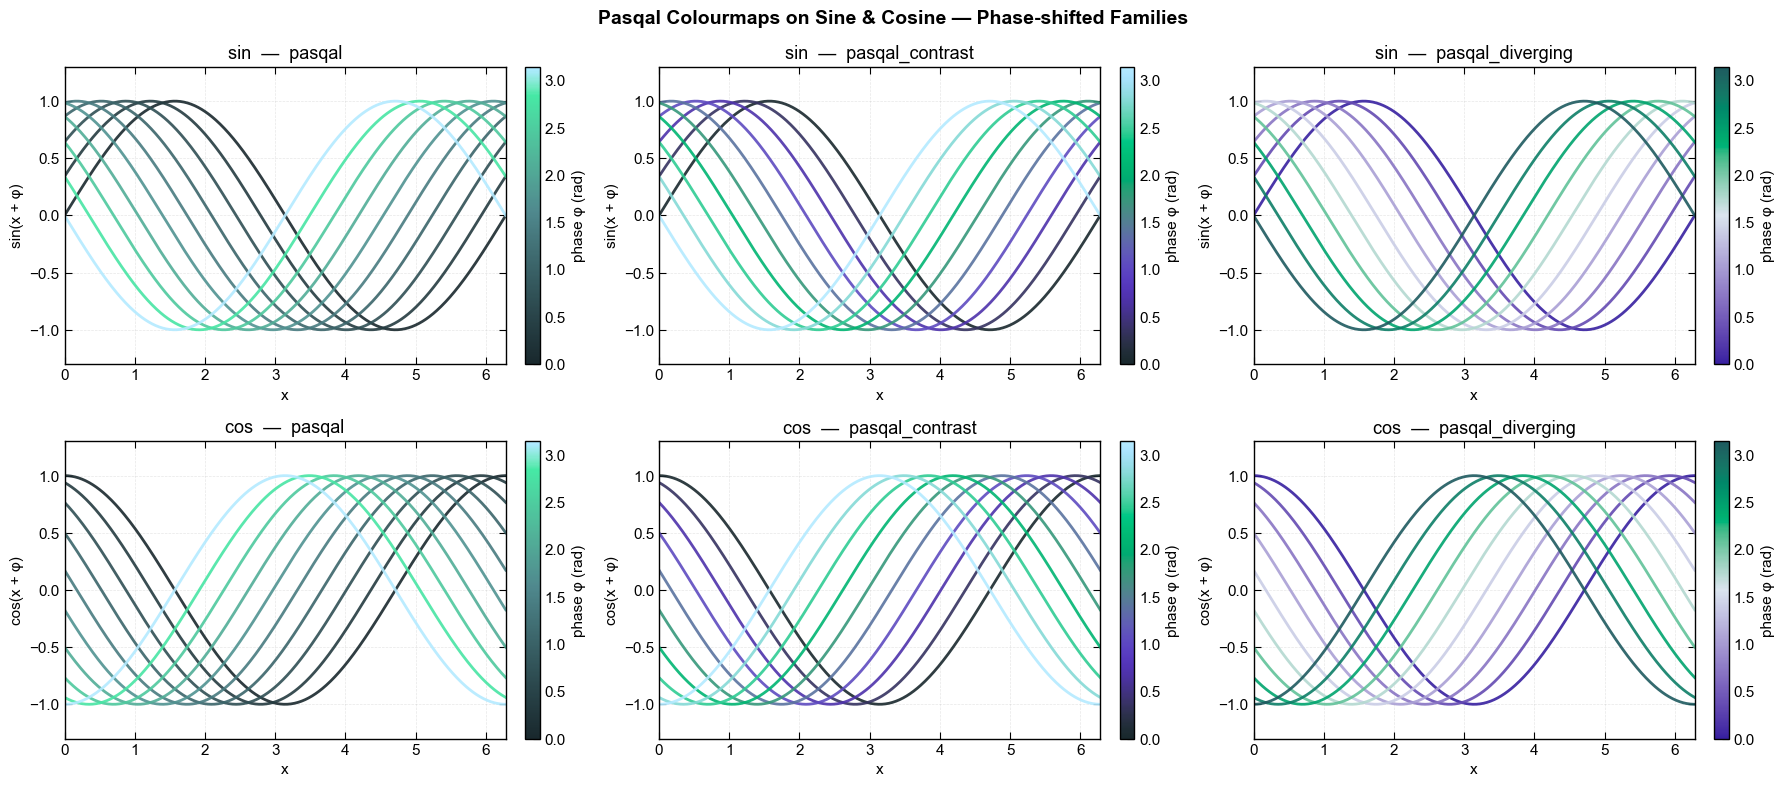

Tip: use  mpl_plt.get_cmap('pasqal_diverging')(t)  for any t ∈ [0, 1] to pick a colour.


In [5]:
# ── Pasqal colourmaps on sine & cosine plots ──────────────────────────────────
import matplotlib.cm as mpl_cm
from matplotlib.colors import Normalize

N_CURVES = 10        # number of phase-shifted curves
x_line   = np.linspace(0, 2 * np.pi, 500)
phases   = np.linspace(0, np.pi, N_CURVES)   # φ ∈ [0, π]

fig, axes = mpl_plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle(
    "Pasqal Colourmaps on Sine & Cosine — Phase-shifted Families",
    fontsize=14, fontweight="bold",
)

for col, cmap_name in enumerate(["pasqal", "pasqal_contrast", "pasqal_diverging"]):
    cmap_obj = mpl_plt.get_cmap(cmap_name)
    norm     = Normalize(vmin=0, vmax=np.pi)

    # ── row 0: sine ──────────────────────────────────────────────────────────
    ax_sin = axes[0, col]
    for i, phi in enumerate(phases):
        color = cmap_obj(i / (N_CURVES - 1))
        ax_sin.plot(x_line, np.sin(x_line + phi),
                    color=color, linewidth=2, alpha=0.9)
    fig.colorbar(
        mpl_cm.ScalarMappable(norm=norm, cmap=cmap_obj),
        ax=ax_sin, label="phase φ (rad)", fraction=0.046, pad=0.04,
    )
    plt.setup_axis(
        ax_sin,
        xlabel="x", ylabel="sin(x + φ)",
        title=f"sin  —  {cmap_name}",
        grid=True, xlim=(0, 2 * np.pi), ylim=(-1.3, 1.3),
    )

    # ── row 1: cosine ────────────────────────────────────────────────────────
    ax_cos = axes[1, col]
    for i, phi in enumerate(phases):
        color = cmap_obj(i / (N_CURVES - 1))
        ax_cos.plot(x_line, np.cos(x_line + phi),
                    color=color, linewidth=2, alpha=0.9)
    fig.colorbar(
        mpl_cm.ScalarMappable(norm=norm, cmap=cmap_obj),
        ax=ax_cos, label="phase φ (rad)", fraction=0.046, pad=0.04,
    )
    plt.setup_axis(
        ax_cos,
        xlabel="x", ylabel="cos(x + φ)",
        title=f"cos  —  {cmap_name}",
        grid=True, xlim=(0, 2 * np.pi), ylim=(-1.3, 1.3),
    )

mpl_plt.tight_layout()
mpl_plt.show()
print("Tip: use  mpl_plt.get_cmap('pasqal_diverging')(t)  for any t ∈ [0, 1] to pick a colour.")